<a href="https://colab.research.google.com/github/marsya505/DataMining/blob/main/Week4-Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
kolom data Train dengan nilai NULL:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------
kolom data Test dengan nilai NULL:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
----------
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
----------
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Title
Mr        517
Miss      182
Mrs 

/tmp/ipykernel_617/907372960.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(), inplace = True)
/tmp/ipykernel_617/907372960.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

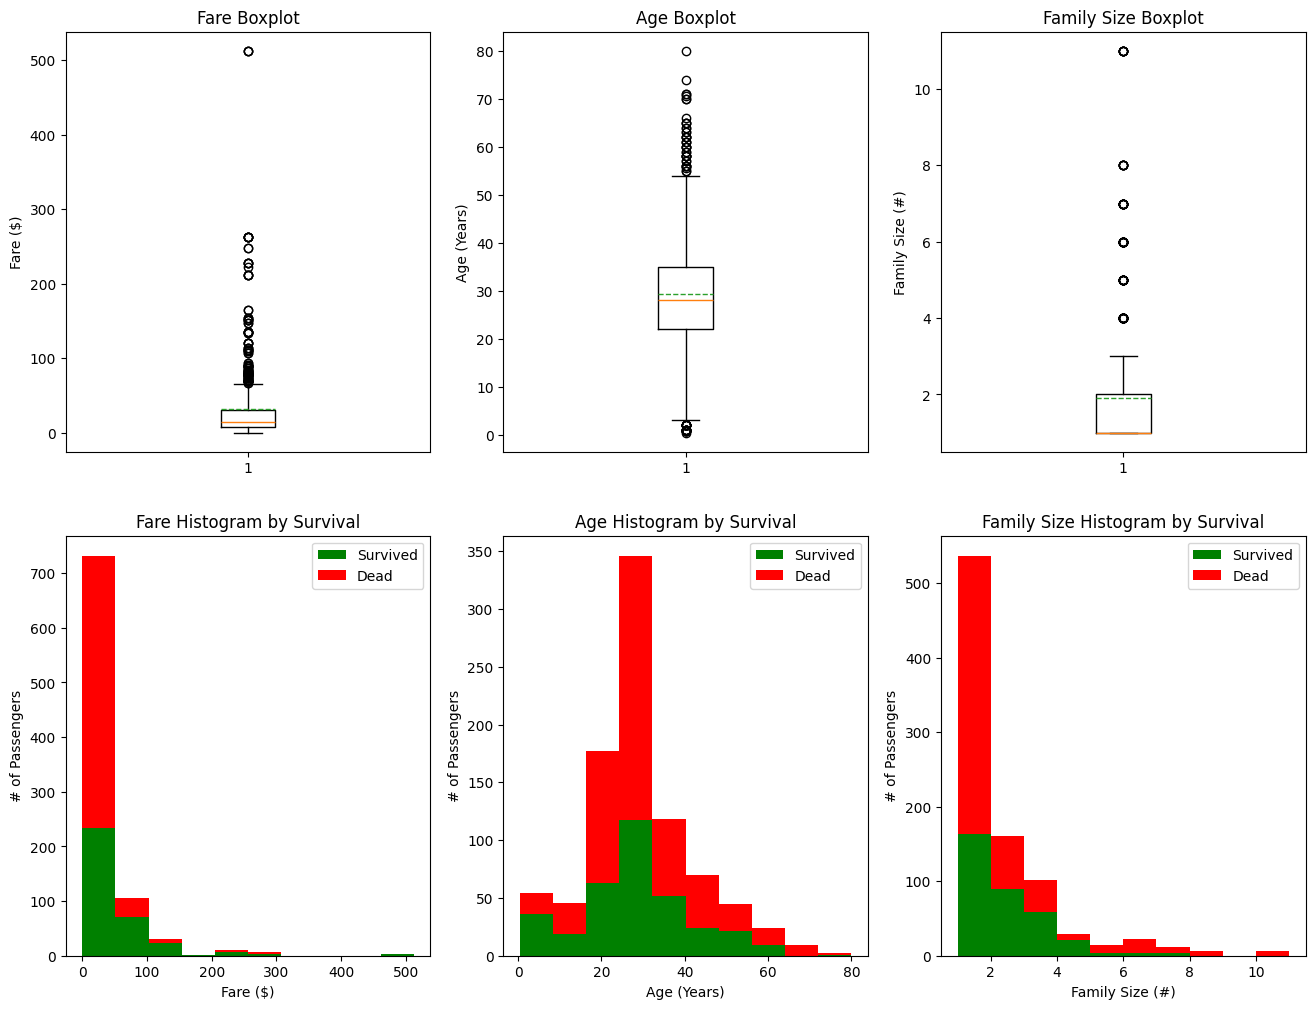

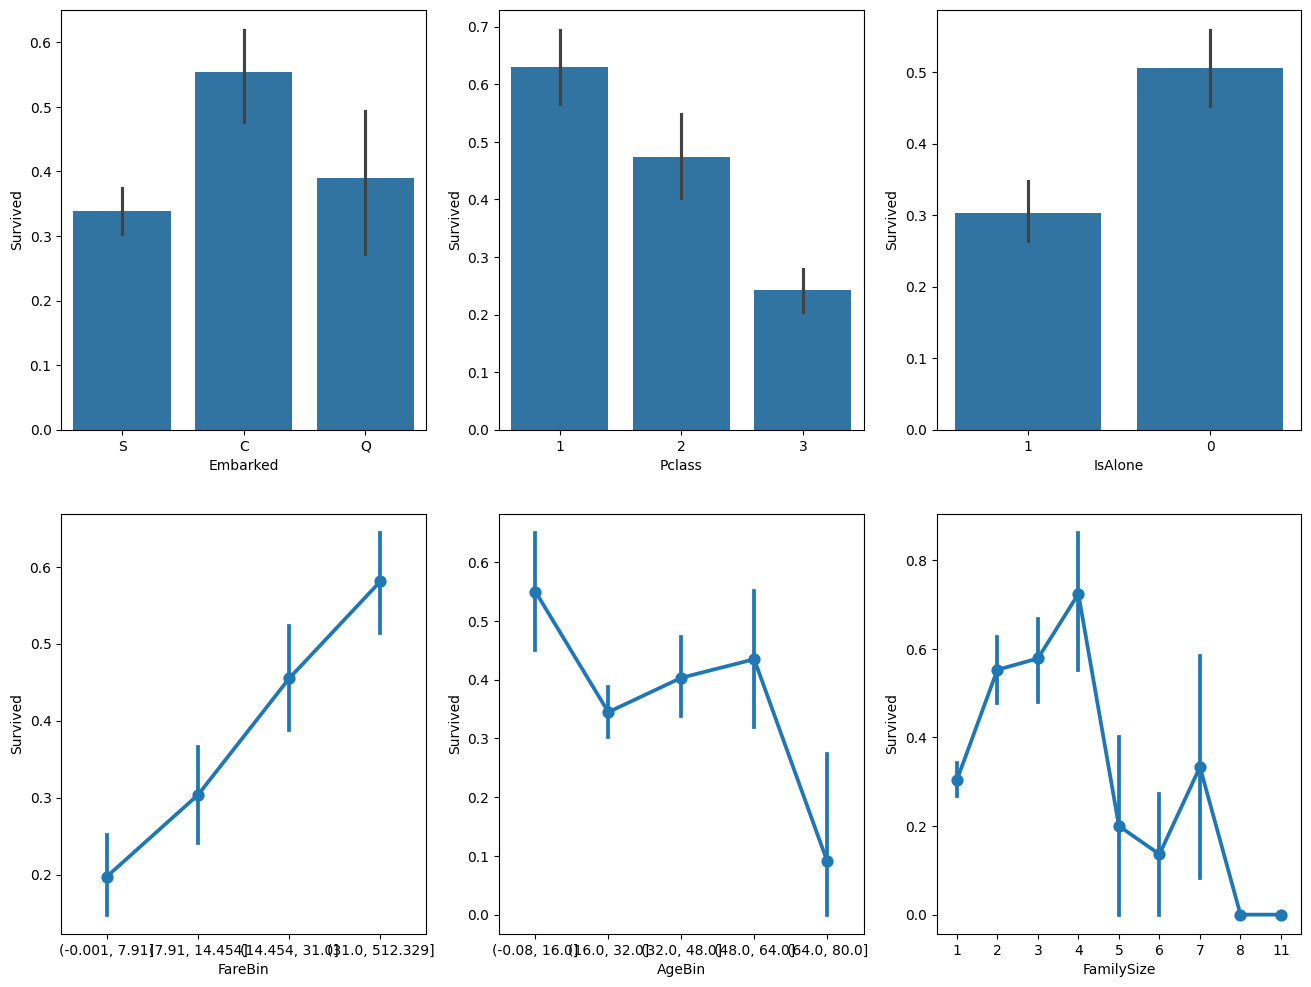

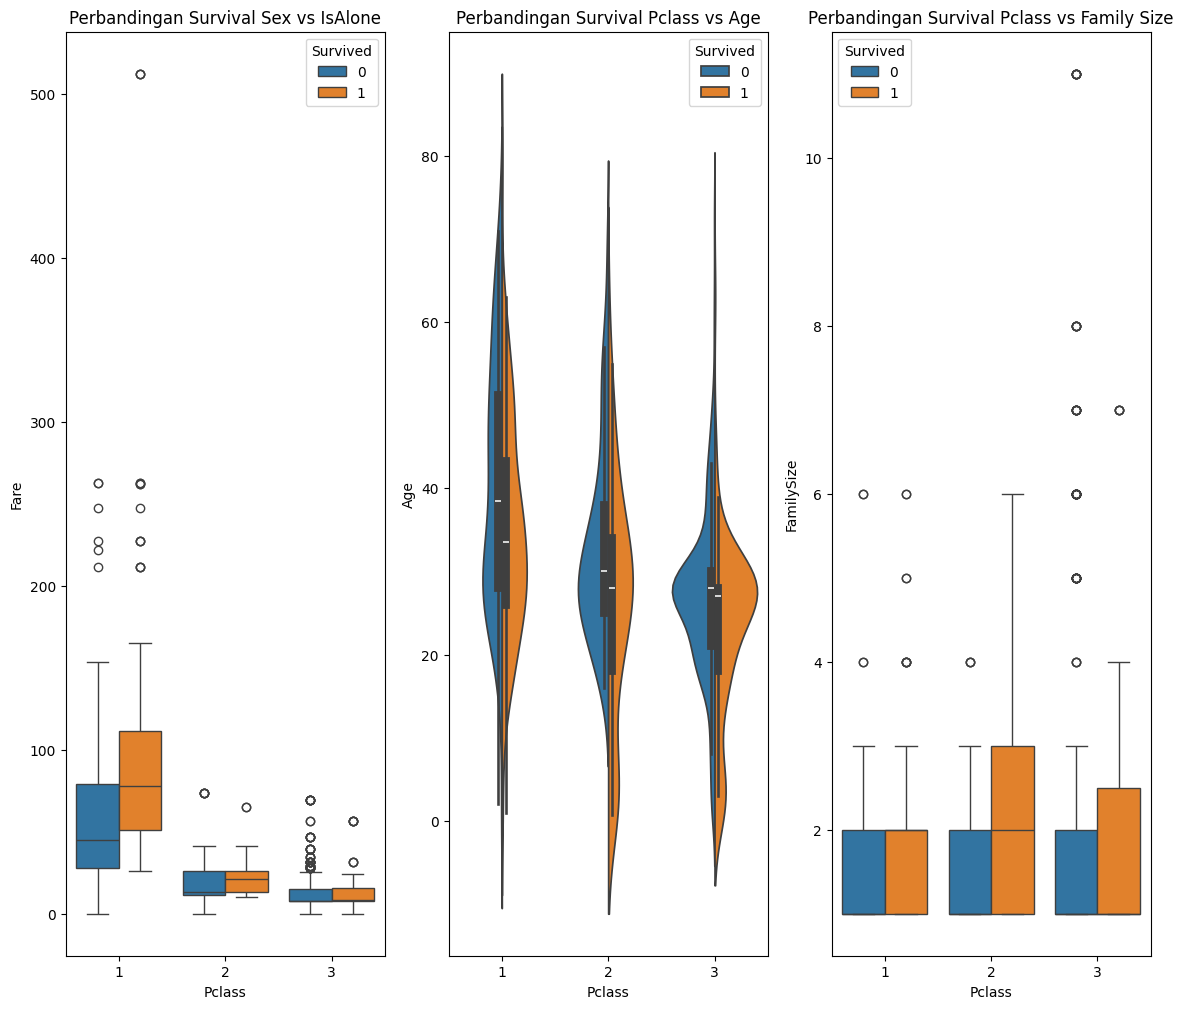

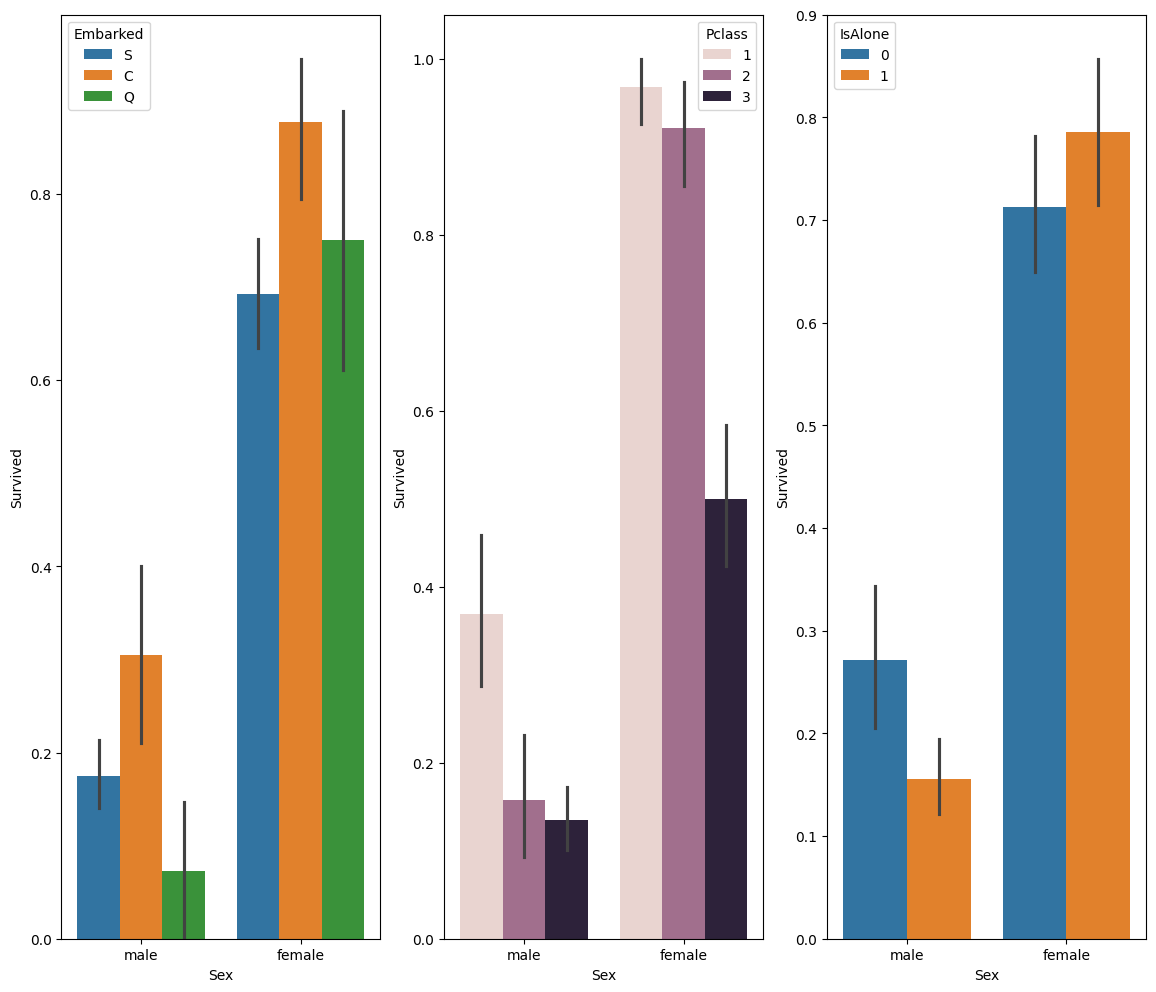

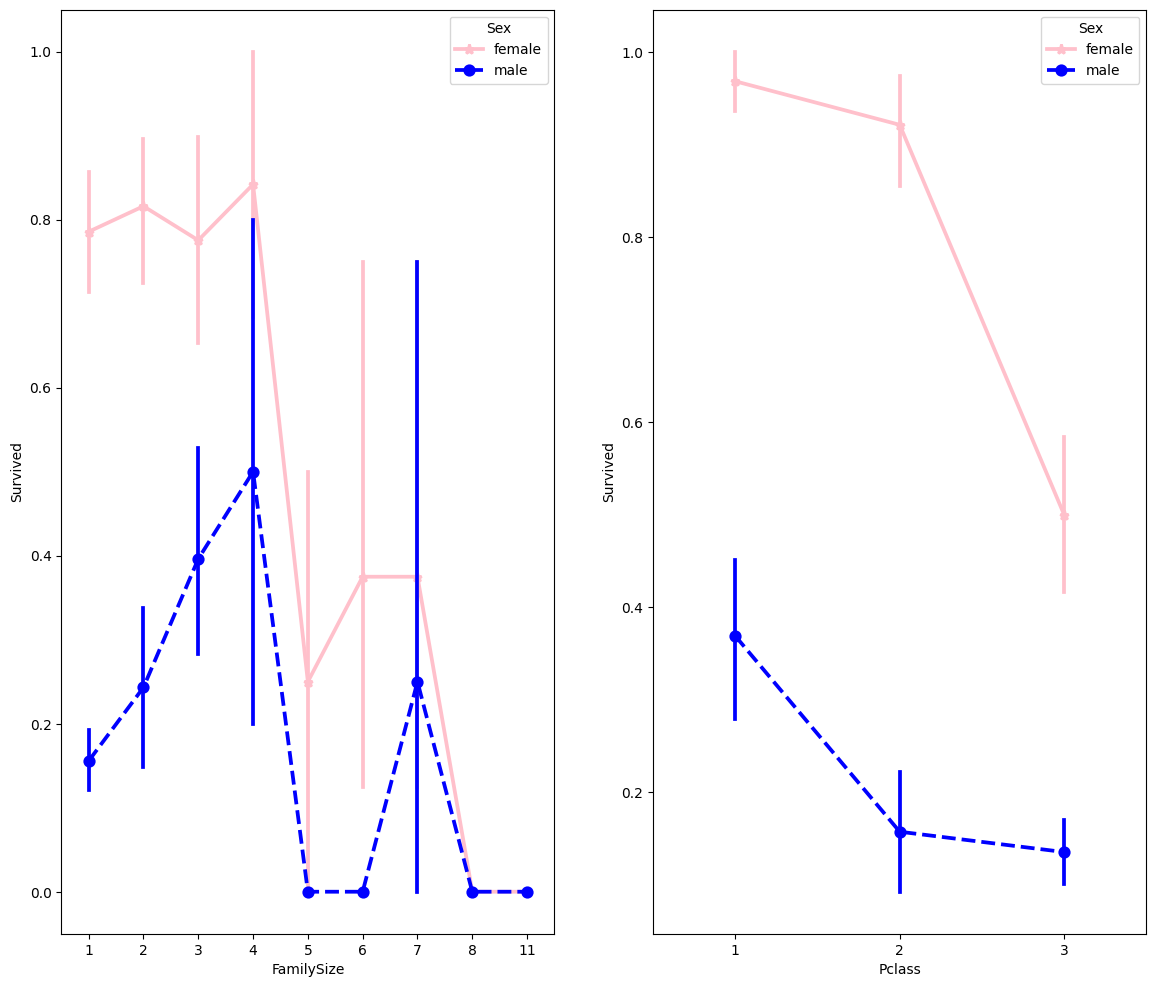

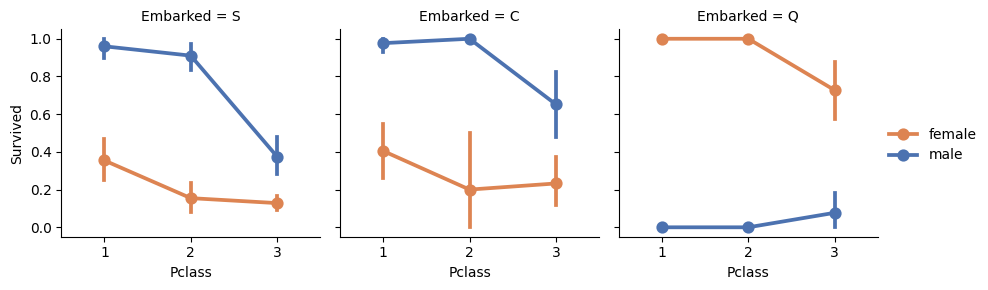

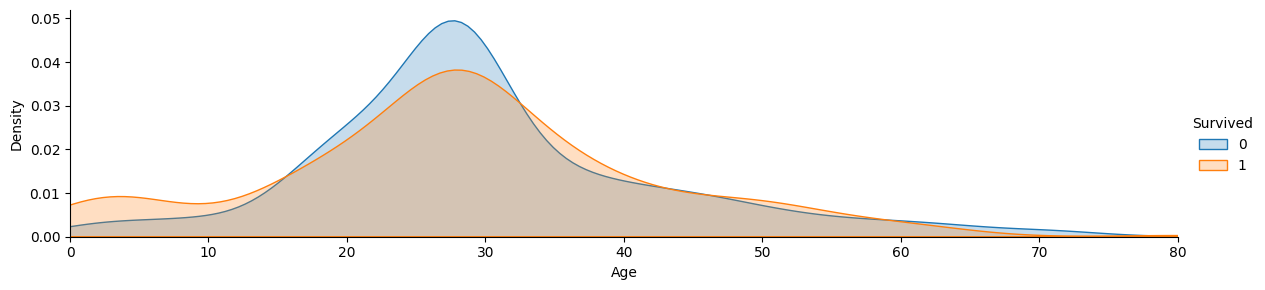

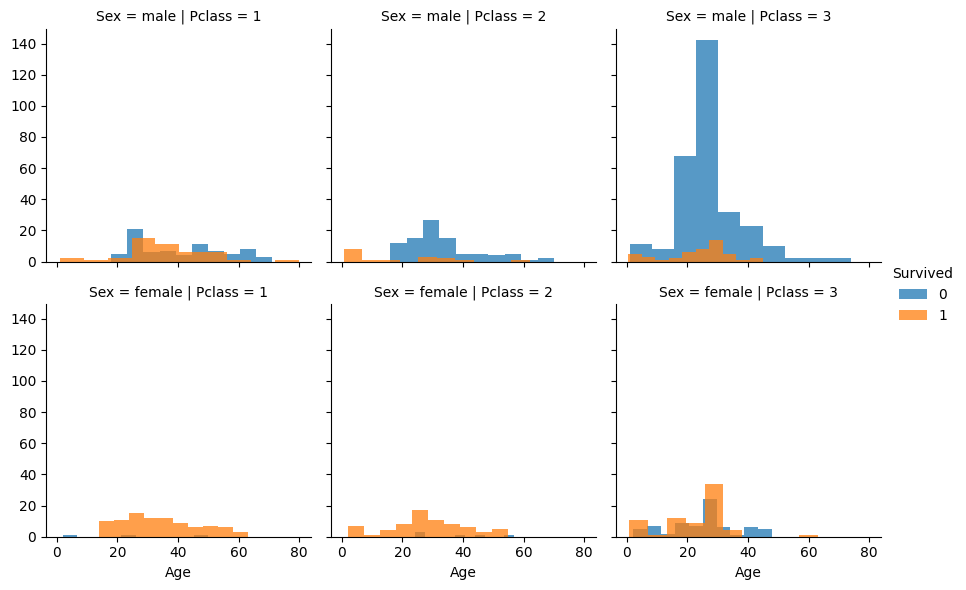

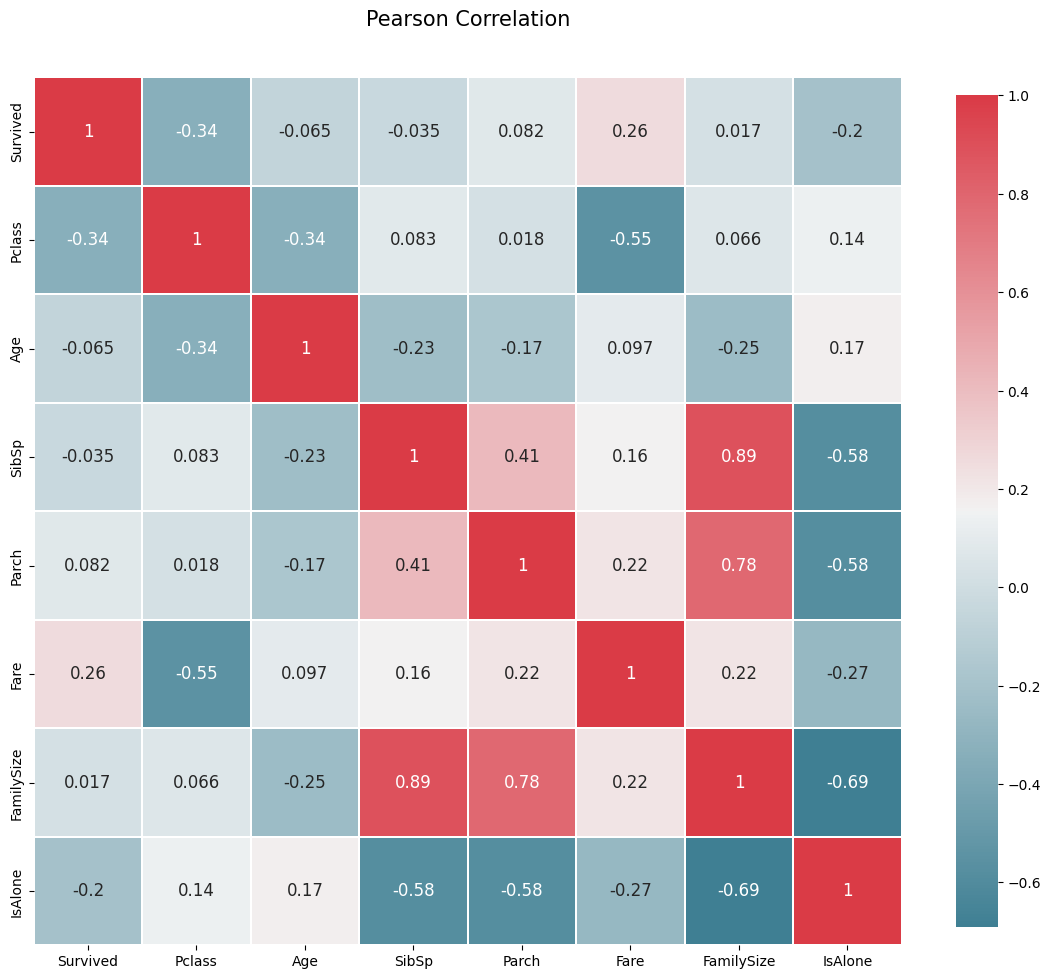

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import model_selection

from google.colab import drive
drive.mount('/content/drive')

data_raw = pd.read_csv('/content/drive/MyDrive/Kuliah/DataMining/Dataset/Titanic/train.csv')
data_val = pd.read_csv('/content/drive/MyDrive/Kuliah/DataMining/Dataset/Titanic/test.csv')

data1 = data_raw.copy(deep = True)

data_cleaner = [data1, data_val]

print('kolom data Train dengan nilai NULL:\n', data1.isnull().sum())
print("-" * 10)

print('kolom data Test dengan nilai NULL:\n', data_val.isnull().sum())
print("-" * 10)

data_raw.describe(include = 'all')

# DATA CLEANING

for dataset in data_cleaner:
    #isikan age yang kosong dengan median
    dataset['Age'].fillna(dataset['Age'].median(), inplace = True)

    #isikan embarked dengan modus
    dataset['Embarked'].fillna(dataset['Embarked'].mode()[0], inplace = True)

    #isikan fare dengan median
    dataset['Fare'].fillna(dataset['Fare'].median(), inplace = True)

#hapus atribut cabin dan lainnya yang kita anggap tidak diperlukan
drop_column = ['PassengerId','Cabin', 'Ticket']
data1.drop(drop_column, axis=1, inplace = True)
data_val.drop(drop_column, axis=1, inplace=True, errors='ignore')

print(data1.isnull().sum())
print("-" * 10)
print(data_val.isnull().sum())

# FEATURE ENGINEERING

for dataset in data_cleaner:
    #variables discrete
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

    dataset['IsAlone'] = 1 #diisikan 1 jika sendiri
    dataset.loc[dataset['FamilySize'] > 1, 'IsAlone'] = 0 # isikan 0 jika ada relasi yang bersama

    #Pisahkan title dari nama: http://www.pythonforbeginners.com/dictionary/python-split
    dataset['Title'] = dataset['Name'].str.split(", ", expand=True)[1].str.split(".", expand=True)[0]

    #Buat bin Fare menggunakan qcut atau bin Frekuensi:
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)

    #buat bin Age menggunakan cut or nilai bin:
    dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)

# CLEAN TITLE YANG JARANG
#bersihkan title yang jarang ada
stat_min = 10
title_names = (data1['Title'].value_counts() < stat_min)

data1['Title'] = data1['Title'].apply(lambda x: 'Misc' if title_names.loc[x] == True else x)
print(data1['Title'].value_counts())
print("-" * 10)

# INFO DATA
#tampilkan data lagi
data1.info()
data_val.info()
data1.sample(10)

# ANALISIS KORELASI
#Discrete Variable Correlation dengan Survival menggunakan
#group by / pivot table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html
Target = ['Survived']
data1_x = [col for col in data1.columns if col != 'Survived']
for x in data1_x:
    if data1[x].dtype != 'float64' and x != 'Name':
        print('Korelasi Survival dengan:', x)
        print(data1[[x, 'Survived']].groupby(x, as_index=False).mean())
        print('-'*10, '\n')

#menggunakan crosstabs: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.crosstab.html
print(pd.crosstab(data1['Title'],data1[Target[0]]))

# VISUALISASI DATA
# Boxplot dan Histogram Dasar
plt.figure(figsize=[16,12])
plt.subplot(231)
plt.boxplot(x=data1['Fare'], showmeans = True, meanline = True)
plt.title('Fare Boxplot')
plt.ylabel('Fare ($)')

plt.subplot(232)
plt.boxplot(data1['Age'], showmeans = True, meanline = True)
plt.title('Age Boxplot')
plt.ylabel('Age (Years)')

plt.subplot(233)
plt.boxplot(data1['FamilySize'], showmeans = True, meanline = True)
plt.title('Family Size Boxplot')
plt.ylabel('Family Size (#)')

plt.subplot(234)
plt.hist(x = [data1[data1['Survived']==1]['Fare'], data1[data1['Survived']==0]['Fare']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Fare Histogram by Survival')
plt.xlabel('Fare ($)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(235)
plt.hist(x = [data1[data1['Survived']==1]['Age'], data1[data1['Survived']==0]['Age']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Age Histogram by Survival')
plt.xlabel('Age (Years)')
plt.ylabel('# of Passengers')
plt.legend()

plt.subplot(236)
plt.hist(x = [data1[data1['Survived']==1]['FamilySize'], data1[data1['Survived']==0]['FamilySize']],
         stacked=True, color = ['g','r'],label = ['Survived','Dead'])
plt.title('Family Size Histogram by Survival')
plt.xlabel('Family Size (#)')
plt.ylabel('# of Passengers')
plt.legend()

# Barplot dan Pointplot
#kita gunakan seaborn untuk perbandingan antar variabel: https://seaborn.pydata.org/api.html
#graph individual features dengan survival
fig, saxis = plt.subplots(2, 3,figsize=(16,12))

sns.barplot(x = 'Embarked', y = 'Survived', data=data1, ax = saxis[0,0])
sns.barplot(x = 'Pclass', y = 'Survived', order=[1,2,3], data=data1, ax = saxis[0,1])
sns.barplot(x = 'IsAlone', y = 'Survived', order=[1,0], data=data1, ax = saxis[0,2])

sns.pointplot(x = 'FareBin', y = 'Survived', data=data1, ax = saxis[1,0])
sns.pointplot(x = 'AgeBin', y = 'Survived', data=data1, ax = saxis[1,1])
sns.pointplot(x = 'FamilySize', y = 'Survived', data=data1, ax = saxis[1,2])

#grafik distribusi dari data kualitatif: Pclass
#Pclass cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandingan Pclass dengan beberapa fitur lain
fig, (axis1,axis2,axis3) = plt.subplots(1,3,figsize=(14,12))

sns.boxplot(x = 'Pclass', y = 'Fare', hue = 'Survived', data = data1, ax = axis1)
axis1.set_title('Perbandingan Survival Pclass vs Fare')

sns.violinplot(x = 'Pclass', y = 'Age', hue = 'Survived', data = data1, split = True, ax = axis2)
axis2.set_title('Perbandingan Survival Pclass vs Age')

sns.boxplot(x = 'Pclass', y = 'FamilySize', hue = 'Survived', data = data1, ax = axis3)
axis3.set_title('Perbandingan Survival Pclass vs Family Size')

#grafik distribusi dari data kualitatif: Sex
#Sex cukup tinggi korelasinya dengan survival, berikut akan ditunjukkan perbandinganSex dengan beberapa fitur lain
fig, qaxis = plt.subplots(1,3,figsize=(14,12))

sns.barplot(x = 'Sex', y = 'Survived', hue = 'Embarked', data=data1, ax = qaxis[0])
axis1.set_title('Perbandingan Survival Sex vs Embarked')

sns.barplot(x = 'Sex', y = 'Survived', hue = 'Pclass', data=data1, ax = qaxis[1])
axis1.set_title('Perbandingan Survival Sex vs Pclass')

sns.barplot(x = 'Sex', y = 'Survived', hue = 'IsAlone', data=data1, ax = qaxis[2])
axis1.set_title('Perbandingan Survival Sex vs IsAlone')

# Grafik Pointplot Perbandingan Lainnya
#contoh grafik perbandingan lainnya
fig, (maxis1, maxis2) = plt.subplots(1, 2,figsize=(14,12))

#bagaimana pengaruh faktor ukuran keluarga terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="FamilySize", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis1)

#bagaimana pengaruh faktor class terhadap perbandingan jenis kelamin dan survival
sns.pointplot(x="Pclass", y="Survived", hue="Sex", data=data1,
              palette={"male": "blue", "female": "pink"},
              markers=["*", "o"], linestyles=["-", "--"], ax = maxis2)

# Pengaruh Port terhadap Pclass, Sex, dan Survival
#bagaimana pengaruh faktor port keberagkatan terhadap perbandingan Pclass, sex, dan survival
#facegrid: https://seaborn.pydata.org/generated/seaborn.FaceGrid.html
e = sns.FacetGrid(data1, col = 'Embarked')
e.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', ci=95.0, palette = 'deep')
e.add_legend()

#plot distribusi dari usia penumpang yang selamat / tidak selamat
a = sns.FacetGrid( data1, hue = 'Survived', aspect=4 )
a.map(sns.kdeplot, 'Age', shade= True )
a.set(xlim=(0 , data1['Age'].max()))
a.add_legend()

#perbandingan histogram dari sex, class, dan age dengan survival
h = sns.FacetGrid(data1, row = 'Sex', col = 'Pclass', hue = 'Survived')
h.map(plt.hist, 'Age', alpha = .75)
h.add_legend()

# Korelasi heatmap dari dataset
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap = True)

    # Hanya dipilih fitur numerik saja
    numerical_df = df.select_dtypes(include=['number'])

    _ = sns.heatmap(
        numerical_df.corr(),
        cmap = colormap,
        square=True,
        cbar_kws={'shrink':.9 },
        ax=ax,
        annot=True,
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    )

    plt.title('Pearson Correlation', y=1.05, size=15)

correlation_heatmap(data1)